# Gradient flows of three discrepancies toward a Gaussian mixture

This notebook generates `fig:gradflow-discrepancy-density-comparison`.  A single pair of one-dimensional Gaussian mixtures is used throughout.  The source law $\alpha_0$ is evolved toward the same target law $\beta$ by three Wasserstein gradient flows:

$$
    f(\alpha)=\mathrm{ED}(\alpha,\beta),\qquad
    f(\alpha)=W_2(\alpha,\beta),\qquad
    f(\alpha)=\mathrm{KL}(\alpha\mid\beta).
$$

The energy-distance and $W_2$ flows are simulated with many equal-weight particles in quantile coordinates.  The KL case is a relative-entropy flow; it is simulated as the Fokker--Planck equation by an implicit finite-volume scheme written in reversible form, so that $\beta$ is the discrete stationary law.  Each exported panel contains only the evolving density curves, colored from red to blue, and a dashed black target density.


In [ ]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root used by this notebook."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing."""
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    pass


In [1]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.sparse import diags, identity
from scipy.sparse.linalg import factorized
from scipy.special import ndtr

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    interp_color,
    setup_matplotlib,
    figure_dir,
    save_pdf,
    box_axes,
)

NAME = "gradflow-discrepancy-density-comparison"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
PDE_OUT = ROOT / "PDE4ML" / "figures" / NAME
THUMB = ROOT / "notebooks-figures" / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
PDE_OUT.mkdir(parents=True, exist_ok=True)
THUMB.mkdir(parents=True, exist_ok=True)
setup_matplotlib()

## Mixtures and one-dimensional representations

Quantile sampling gives deterministic equal-weight particles for the two particle flows.  For the energy distance, the one-dimensional identity

$$
    \mathrm{ED}^2(\alpha,\beta)=2\int_{\mathbb R}|F_\alpha(x)-F_\beta(x)|^2\,dx
$$

makes it possible to evaluate the velocity through empirical ranks and the target CDF.  The target is deliberately bimodal while the source is shifted to the left, so that the three geometries have visibly different transient behaviors.


In [2]:
# Common one-dimensional source and target mixtures.
# The same pair is used in all three flows.
alpha_weights = np.array([0.58, 0.42])
alpha_means = np.array([-2.05, -0.35])
alpha_sigmas = np.array([0.23, 0.36])

beta_weights = np.array([0.40, 0.60])
beta_means = np.array([-0.62, 1.32])
beta_sigmas = np.array([0.34, 0.32])

x_min, x_max = -3.35, 2.75
nx = 1600
x_grid = np.linspace(x_min, x_max, nx)
dx = x_grid[1] - x_grid[0]

def mix_pdf(x, weights, means, sigmas):
    """Evaluate the mix probability density on the current grid."""
    x = np.asarray(x)
    z = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, sigmas):
        z += w * np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    return z

def mix_cdf(x, weights, means, sigmas):
    """Compute cumulative distribution values for the one-dimensional discretization."""
    x = np.asarray(x)
    z = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, sigmas):
        z += w * ndtr((x - m) / s)
    return z

alpha0_pdf = mix_pdf(x_grid, alpha_weights, alpha_means, alpha_sigmas)
beta_pdf = mix_pdf(x_grid, beta_weights, beta_means, beta_sigmas)
alpha0_pdf /= np.trapezoid(alpha0_pdf, x_grid)
beta_pdf /= np.trapezoid(beta_pdf, x_grid)
beta_cdf_grid = np.cumsum(beta_pdf) * dx
beta_cdf_grid /= beta_cdf_grid[-1]

def quantiles_from_pdf(pdf, n):
    """Evaluate the quantiles from probability density on the current grid."""
    cdf = np.cumsum(pdf) * dx
    cdf /= cdf[-1]
    u = (np.arange(n) + 0.5) / n
    return np.interp(u, cdf, x_grid)

def kde_from_particles(z, bw=0.052):
    """Return KDE from particles for the current computation."""
    hist, _ = np.histogram(z, bins=nx, range=(x_min, x_max), density=False)
    density = hist.astype(float) / (len(z) * dx)
    density = gaussian_filter1d(density, bw / dx, mode="constant")
    mass = np.trapezoid(density, x_grid)
    if mass > 0:
        density /= mass
    return density


## Numerical flows

The $W_2$ distance is computed in quantile variables.  For ED and $W_2$ we descend the unsquared discrepancy, so the velocity is normalized by the current discrepancy value away from the target.  The KL flow uses

$$
    \partial_t \rho_t = \partial_x\left(\rho_\beta\,\partial_x\left(\frac{\rho_t}{\rho_\beta}\right)\right),
$$

which is the Wasserstein gradient flow of $\mathrm{KL}(\rho_t\,dx\mid \beta)$.  The finite-volume discretization below is conservative and has the sampled target density as an exact stationary state.


In [3]:
def simulate_ed(n=8000, steps=860, dt=0.0048, snapshots=10):
    """Wasserstein particle flow of the energy distance to beta.

    In one dimension the energy distance satisfies
    ED^2(alpha,beta)=2 int |F_alpha-F_beta|^2 dx.  The Wasserstein
    velocity of ED is the velocity of ED^2 divided by 2 ED; a small floor
    only regularizes the terminal stage close to beta.
    """
    z = quantiles_from_pdf(alpha0_pdf, n).copy()
    snap_ids = np.linspace(0, steps, snapshots).round().astype(int)
    curves = []
    for it in range(steps + 1):
        if it in snap_ids:
            curves.append(kde_from_particles(z, bw=0.056))
        if it == steps:
            break
        order = np.argsort(z)
        zs = z[order]
        F_alpha = (np.arange(n) + 0.5) / n
        F_beta = mix_cdf(zs, beta_weights, beta_means, beta_sigmas)
        diff = np.interp(x_grid, zs, F_alpha, left=0.0, right=1.0) - beta_cdf_grid
        ed2 = max(2.0 * np.trapezoid(diff * diff, x_grid), 1e-12)
        velocity_sorted = 2.0 * (F_alpha - F_beta) / max(np.sqrt(ed2), 0.075)
        z[order] = zs + dt * velocity_sorted
    return curves

def simulate_w2(n=8000, steps=760, dt=0.0038, snapshots=10):
    """Wasserstein particle flow of W2(alpha,beta) in quantile variables."""
    z = quantiles_from_pdf(alpha0_pdf, n).copy()
    y = quantiles_from_pdf(beta_pdf, n)
    snap_ids = np.linspace(0, steps, snapshots).round().astype(int)
    curves = []
    for it in range(steps + 1):
        order = np.argsort(z)
        zs = z[order]
        if it in snap_ids:
            curves.append(kde_from_particles(zs, bw=0.052))
        if it == steps:
            break
        w2 = np.sqrt(np.mean((zs - y) ** 2))
        velocity_sorted = -(zs - y) / max(w2, 0.07)
        z[order] = zs + dt * velocity_sorted
    return curves

def simulate_kl(steps=1500, dt=0.018, snapshots=10):
    """Implicit finite-volume Fokker--Planck flow of KL(alpha|beta).

    The equation is written in reversible form
        partial_t rho = partial_x( beta partial_x(rho/beta) ),
    so the discrete target beta is an exact stationary state.
    """
    rho = alpha0_pdf.copy()
    beta = np.maximum(beta_pdf.copy(), 1e-14)
    beta_edge = 0.5 * (beta[:-1] + beta[1:])

    main = np.zeros(nx)
    lower = np.zeros(nx - 1)
    upper = np.zeros(nx - 1)
    for i, be in enumerate(beta_edge):
        coeff = be / (dx * dx)
        main[i] -= coeff / beta[i]
        main[i + 1] -= coeff / beta[i + 1]
        upper[i] += coeff / beta[i + 1]
        lower[i] += coeff / beta[i]
    L = diags([lower, main, upper], [-1, 0, 1], shape=(nx, nx), format="csc")
    solve = factorized(identity(nx, format="csc") - dt * L)

    snap_ids = np.linspace(0, steps, snapshots).round().astype(int)
    curves = []
    for it in range(steps + 1):
        if it in snap_ids:
            curves.append(rho.copy())
        if it == steps:
            break
        rho = np.maximum(solve(rho), 1e-16)
        rho /= np.trapezoid(rho, x_grid)
    return curves

curves_ed = simulate_ed()
curves_w2 = simulate_w2()
curves_kl = simulate_kl()


## Exported panels

The paper assembles the three PDFs directly in LaTeX, so the exported panels do not contain titles.  The notebook thumbnail below adds labels only for the figure gallery.  The same run exports the nested OT4ML/PDE4ML files and the flattened arXiv files.


In [4]:
def save_panel(name, curves, target, *, ymax=None):
    """Save panel to the figure or thumbnail outputs."""
    if ymax is None:
        ymax = max(np.max(c) for c in curves + [target]) * 1.08
    fig, ax = plt.subplots(figsize=(2.62, 1.76))
    for k, c in enumerate(curves):
        t = k / (len(curves) - 1)
        lw = 1.45 if k in (0, len(curves) - 1) else 1.18
        ax.plot(x_grid, c, color=interp_color(t), lw=lw, alpha=0.97, zorder=2 + k)
    ax.plot(x_grid, target, color="#171717", lw=0.9, ls=(0, (3.0, 2.0)), alpha=0.78, zorder=1)
    ax.axhline(0, color="#222222", lw=0.35, alpha=0.55, zorder=0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
    save_pdf(fig, OUT / f"{name}.pdf", pad_inches=0.018)
    fig.savefig(ARXIV_OUT / f"{NAME}--{name}.pdf", bbox_inches="tight", pad_inches=0.018)
    fig.savefig(PDE_OUT / f"{name}.pdf", bbox_inches="tight", pad_inches=0.018)
    return fig

ymax = 1.12 * max(np.max(c) for curves in [curves_ed, curves_w2, curves_kl] for c in curves + [beta_pdf])
fig_ed = save_panel("energy-distance", curves_ed, beta_pdf, ymax=ymax)
fig_w2 = save_panel("w2", curves_w2, beta_pdf, ymax=ymax)
fig_kl = save_panel("kl", curves_kl, beta_pdf, ymax=ymax)
plt.close("all")


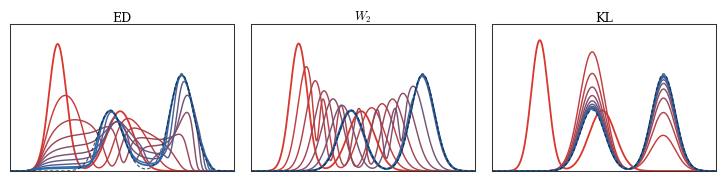

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(7.25, 1.82), sharex=True, sharey=True)
for ax, curves, title in zip(axes, [curves_ed, curves_w2, curves_kl], ["ED", r"$W_2$", "KL"]):
    for k, c in enumerate(curves):
        t = k / (len(curves) - 1)
        lw = 1.30 if k in (0, len(curves) - 1) else 1.04
        ax.plot(x_grid, c, color=interp_color(t), lw=lw, alpha=0.97)
    ax.plot(x_grid, beta_pdf, color="#171717", lw=0.82, ls=(0, (3.0, 2.0)), alpha=0.75)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=9, pad=1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
fig.subplots_adjust(wspace=0.075, left=0.018, right=0.992, top=0.86, bottom=0.055)
fig.savefig(THUMB / f"{NAME}.png", dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()


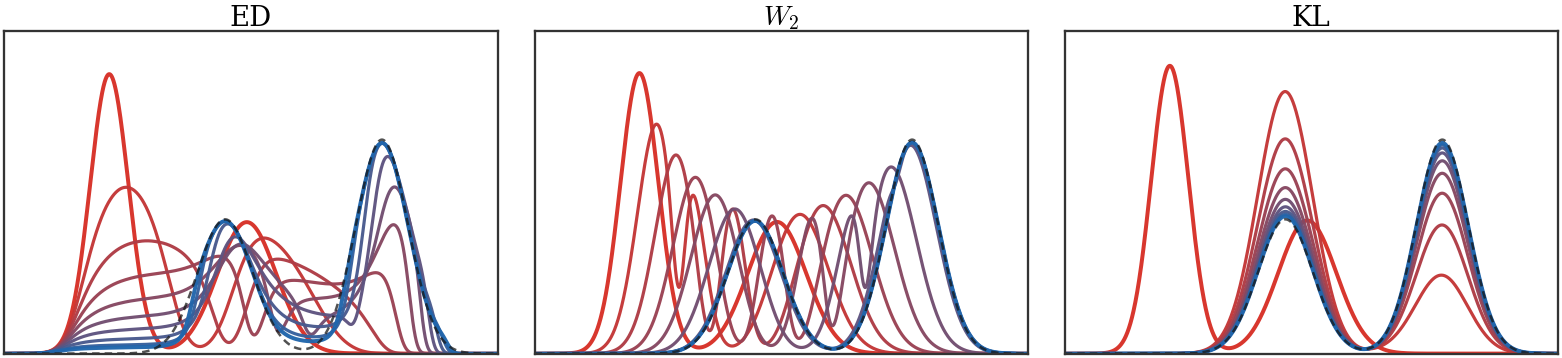

In [6]:
from IPython.display import Image, display
thumb = THUMB / f"{NAME}.png"
display(Image(filename=str(thumb), width=900))